<a href="https://colab.research.google.com/github/SSClements/INDE2000-Project/blob/main/INDE2000_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Library used**

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf


from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [29]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

# **Import Data**

In [30]:
file_names = [
    '2010-2011 Solar home electricity data.csv',
    '2011-2012 Solar home electricity data v2.csv',
    '2012-2013 Solar home electricity data v2.csv'
]

all_years_list = []

for name in file_names:

    try:
        # header=1 to skip the PDF description row
        temp_df = pd.read_csv(name, header=1)

        # Clean column names just in case
        temp_df.columns = [str(col).strip().lower() for col in temp_df.columns]

        # Find 'Date' and 'Category' by position or keyword
        date_col = next((c for c in temp_df.columns if 'date' in c), None)
        cat_col = next((c for c in temp_df.columns if 'consumption' in c or 'category' in c), None)

        if not date_col or not cat_col:
            print(f"Skipping {name}: Missing Date/Category columns.")
            continue

        # Select 48 columns by position (The last 48 columns)
        # In Ausgrid files, the 48 half-hour slots are always the last 48 columns.
        # Take the last 48 columns and rename them to 1-48 for consistency.
        power_data_cols = temp_df.columns[-48:].tolist()

        # Filter for General Consumption (GC)
        temp_gc = temp_df[temp_df[cat_col].astype(str).str.contains('GC', case=False, na=False)].copy()

        # Ensure data is numeric
        for col in power_data_cols:
            temp_gc[col] = pd.to_numeric(temp_gc[col], errors='coerce')

        # Aggregate: Mean of ALL customers
        daily_avg = temp_gc.groupby(date_col)[power_data_cols].mean().reset_index()

        # Rename columns to standard: 'Date', '1', '2', ..., '48'
        standard_names = ['Date'] + [str(i) for i in range(1, 49)]
        daily_avg.columns = standard_names

        all_years_list.append(daily_avg)
        print(f"SUCCESS: Processed {name} with 48 time slots.")

        del temp_df, temp_gc

    except Exception as e:
        print(f"Error at {name}: {e}")


SUCCESS: Processed 2010-2011 Solar home electricity data.csv with 48 time slots.
SUCCESS: Processed 2011-2012 Solar home electricity data v2.csv with 48 time slots.
SUCCESS: Processed 2012-2013 Solar home electricity data v2.csv with 48 time slots.


# **Transformation, Deseasonalization and Visualization**

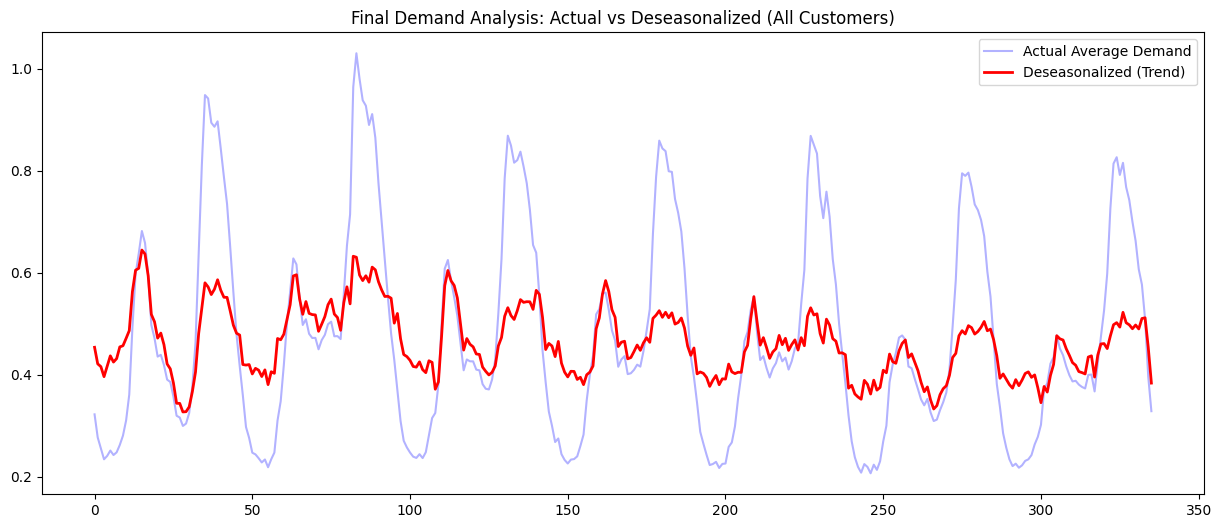

In [31]:
if all_years_list:
    df_combined = pd.concat(all_years_list, ignore_index=True)

    # Transformation
    time_periods = [str(i) for i in range(1, 49)]
    df_long = df_combined.melt(id_vars=['Date'], value_vars=time_periods,
                               var_name='Period', value_name='Avg_kWh')

    df_long['Date'] = pd.to_datetime(df_long['Date'], dayfirst=True)
    df_long['Period'] = df_long['Period'].astype(int)
    df_long = df_long.sort_values(['Date', 'Period']).reset_index(drop=True)

    # Deseasonalization (Lecture 6)
    grand_mean = df_long['Avg_kWh'].mean()
    seasonal_indices = df_long.groupby('Period')['Avg_kWh'].mean() / grand_mean
    df_long['Seasonal_Index'] = df_long['Period'].map(seasonal_indices)
    df_long['Deseasonalized_kWh'] = df_long['Avg_kWh'] / df_long['Seasonal_Index']

    # Visualization
    plt.figure(figsize=(15, 6))
    plt.plot(df_long['Avg_kWh'][:336], label='Actual Average Demand', color='blue', alpha=0.3)
    plt.plot(df_long['Deseasonalized_kWh'][:336], label='Deseasonalized (Trend)', color='red', linewidth=2)
    plt.title('Final Demand Analysis: Actual vs Deseasonalized (All Customers)')
    plt.legend()
    plt.show()
else:
    print("Check if your files are actually .csv and have 48 data columns at the end.")

In [32]:
# Counting NA values for total data
na_count = df_long['Avg_kWh'].isna().sum()
total_count = len(df_long)
na_pct = (na_count / total_count) * 100
print(f"Missing values (NA): {na_count} out of {total_count} ({na_pct:.2f}%)")

# Document Data
## Total Entries, Missing Data, Percentage
for i, df in enumerate(all_years_list):
    year_label = file_names[i].split('/')[-1][:9]

    non_missing = df.iloc[:, 1:].count().sum()
    total_cells = df.iloc[:, 1:].size
    missing = total_cells - non_missing
    missing_pct = (missing / total_cells) * 100

    print(f"  {year_label} | Total: {total_cells} | Missing: {missing} | ({missing_pct:.2f}%)")


Missing values (NA): 731 out of 52608 (1.39%)
  2010-2011 | Total: 17520 | Missing: 0 | (0.00%)
  2011-2012 | Total: 17568 | Missing: 366 | (2.08%)
  2012-2013 | Total: 17520 | Missing: 365 | (2.08%)


In [33]:
# Outliers
mean_val = df_long['Deseasonalized_kWh'].mean()
std_val = df_long['Deseasonalized_kWh'].std()
outliers = df_long[(df_long['Deseasonalized_kWh'] < mean_val - 3*std_val) |
                   (df_long['Deseasonalized_kWh'] > mean_val + 3*std_val)]

total_count = len(df_long)
print(f"Outliers (±3 std): {len(outliers)} out of {total_count} ({(len(outliers)/total_count)*100:.2f}%)")



Outliers (±3 std): 631 out of 52608 (1.20%)


In [34]:
print(outliers[['Date', 'Period', 'Avg_kWh', 'Deseasonalized_kWh']].sort_values('Deseasonalized_kWh', ascending=False).head(20))

            Date  Period   Avg_kWh  Deseasonalized_kWh
10541 2011-02-05      30  1.286773            1.385441
10540 2011-02-05      29  1.235820            1.349161
10542 2011-02-05      31  1.300290            1.347914
10539 2011-02-05      28  1.210897            1.317120
10538 2011-02-05      27  1.203817            1.295787
10543 2011-02-05      32  1.329047            1.291208
10537 2011-02-05      26  1.166850            1.254165
10536 2011-02-05      25  1.118087            1.192858
10544 2011-02-05      33  1.334213            1.169576
10535 2011-02-05      24  1.071133            1.155227
44764 2013-01-18      29  1.010530            1.103209
10534 2011-02-05      23  0.985903            1.079880
44765 2013-01-18      30  1.000880            1.077626
10585 2011-02-06      26  0.989167            1.063186
44766 2013-01-18      31  1.002337            1.039048
10584 2011-02-06      25  0.969457            1.034289
44285 2013-01-08      30  0.949737            1.022561
44763 2013

Outliers are during peak summer season, keep them in

# Model Formulation

hi these models are currently just using all three years to be created and then plotting their predictions of those same three years. I have not done a train/test split ratio to test accuracy of forecasting future data


also please let me know if it looks wrong or you think we should approach differently


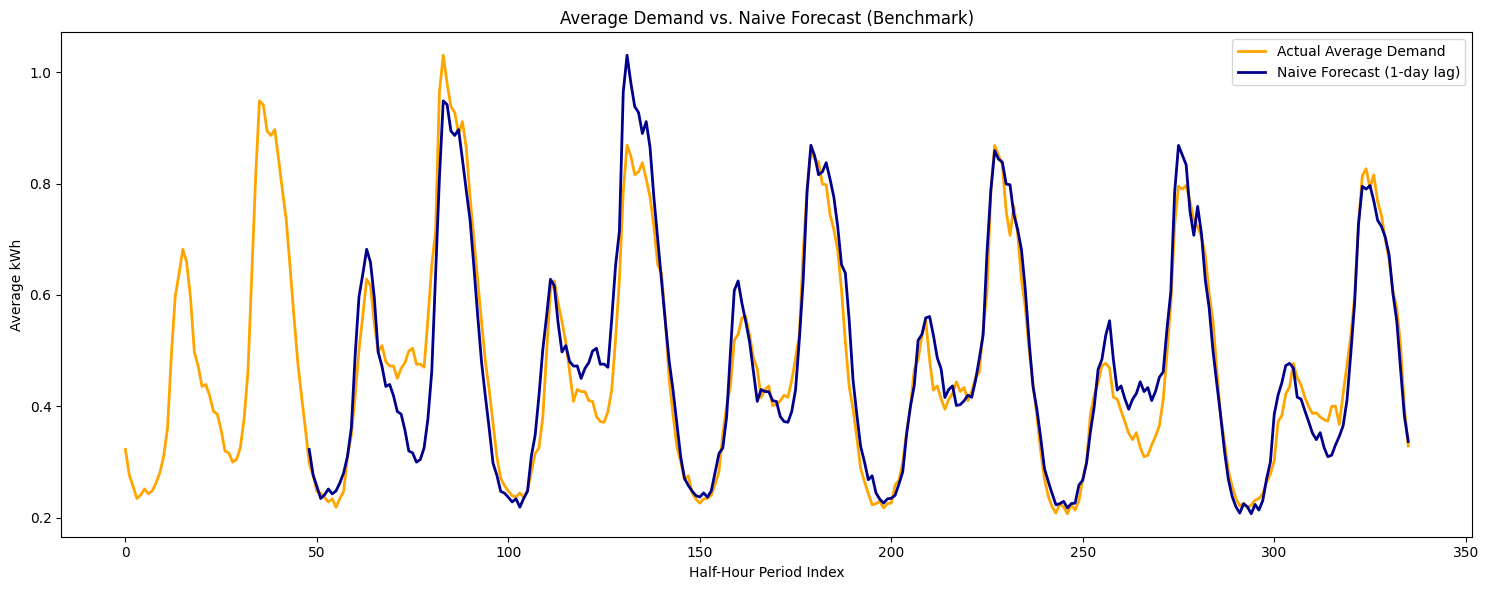

In [35]:
# Naive Forecast (Seasonal Naive - 1 day lag on deseasonalized series)

# Shift by 48 periods (one full day of 30-min intervals)
df_long['Naive_Deseasonalized'] = df_long['Deseasonalized_kWh'].shift(48)

# Re-seasonalize
df_long['Naive'] = df_long['Naive_Deseasonalized'] * df_long['Seasonal_Index']

# Plot - first week (336 periods)
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Actual Average Demand', color='orange', linewidth=2)
plt.plot(df_long['Naive'][:336], label='Naive Forecast (1-day lag)', color='darkblue', linewidth=2)
plt.title('Average Demand vs. Naive Forecast (Benchmark)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
print(df_long['Deseasonalized_kWh'].dtype)
print(df_long['Deseasonalized_kWh'].isna().sum())
print(df_long['Deseasonalized_kWh'].head(10))
print()
print(np.asarray(df_long['Deseasonalized_kWh'][:10]))

float64
731
0    0.453915
1    0.421402
2    0.415968
3    0.396315
4    0.416779
5    0.437156
6    0.424919
7    0.431726
8    0.454633
9    0.456938
Name: Deseasonalized_kWh, dtype: float64

[0.4539154  0.42140152 0.41596836 0.39631494 0.41677881 0.4371555
 0.42491891 0.43172599 0.45463348 0.4569378 ]


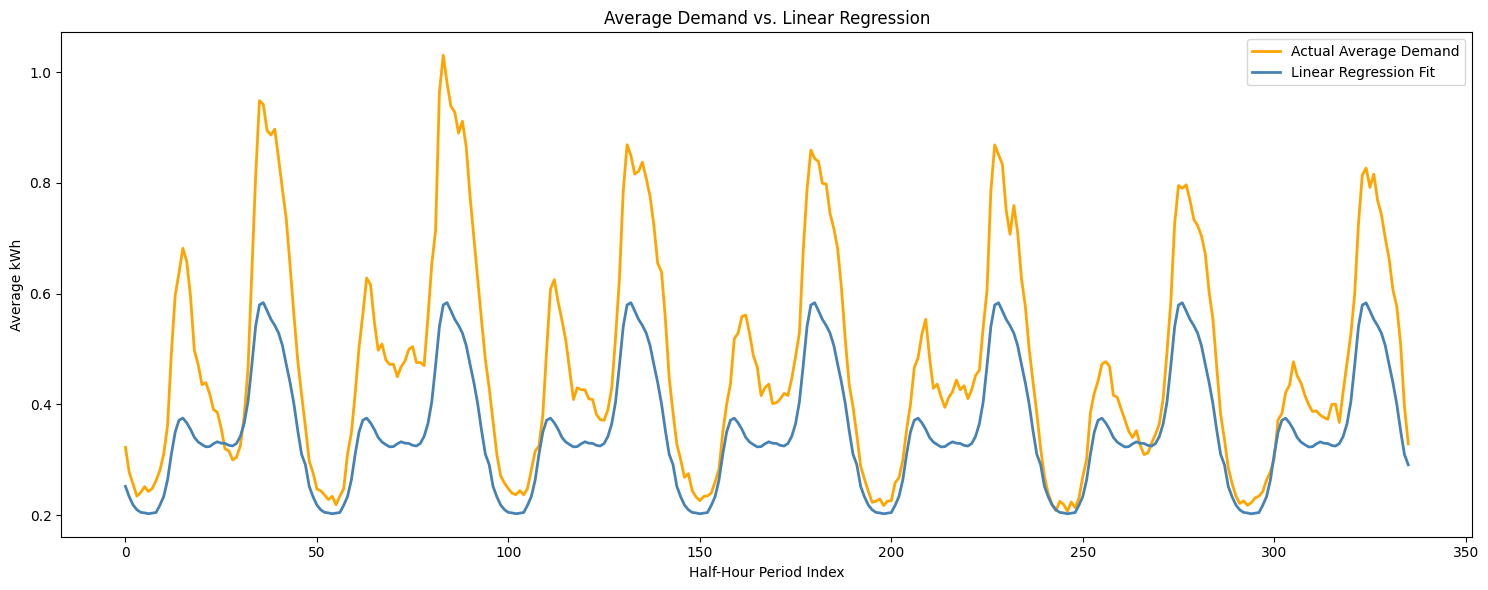

In [39]:
# Linear Regression on Deseasonalized Series

# Drop NaNs and reset index so X and y align
mask = df_long['Deseasonalized_kWh'].notna()
y = df_long.loc[mask, 'Deseasonalized_kWh'].astype(float).reset_index(drop=True)

t_vals = np.arange(mask.sum())
period_dummies = pd.get_dummies(df_long.loc[mask, 'Period'], prefix='P', drop_first=True).astype(float).reset_index(drop=True)

X = pd.concat([pd.Series(t_vals, name='t'), period_dummies], axis=1)
X = sm.add_constant(X)

# Store fitted values and re-seasonalize

df_long['LR_Deseasonalized'] = model_lr.fittedvalues
df_long['LR'] = df_long['LR_Deseasonalized'] * df_long['Seasonal_Index']

# Plot - first week
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Actual Average Demand', color='orange', linewidth=2)
plt.plot(df_long['LR'][:336], label='Linear Regression Fit', color='steelblue', linewidth=2)
plt.title('Average Demand vs. Linear Regression')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

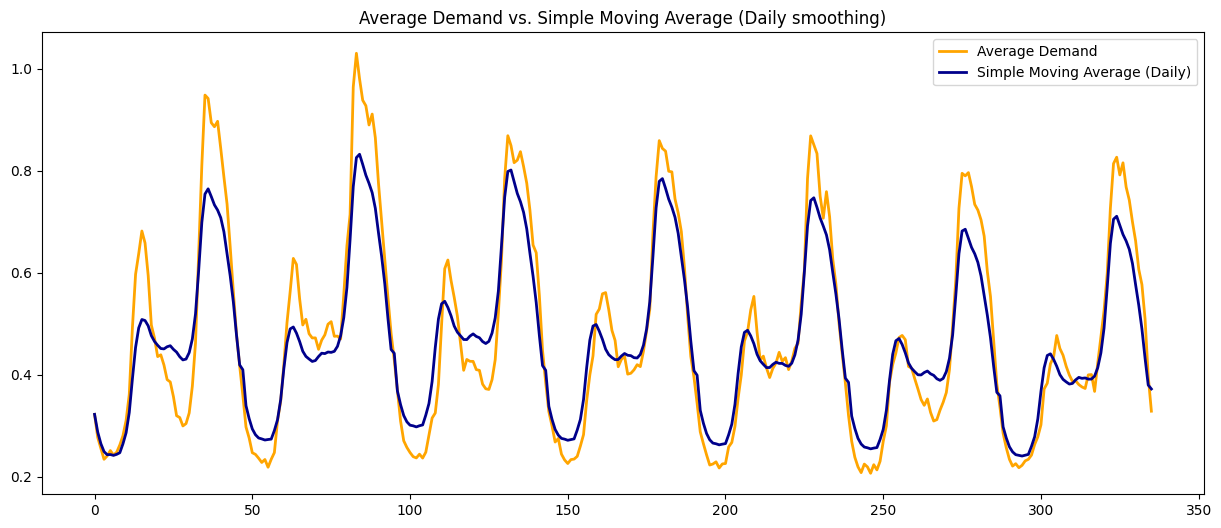

In [40]:
# Simple Moving Average

## One day smoothing (30 min intervals)
df_long['SMA_48_Deseasonalized'] = df_long.Deseasonalized_kWh.rolling(48, min_periods=1).mean()

## Re-seasonalisation
df_long['SMA_48'] = df_long['SMA_48_Deseasonalized'] * df_long['Seasonal_Index']

# Simple Moving Average Plot

plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['SMA_48'][:336], label='Simple Moving Average (Daily)', color='darkblue', linewidth=2)
plt.title('Average Demand vs. Simple Moving Average (Daily smoothing)')
plt.legend()
plt.show()

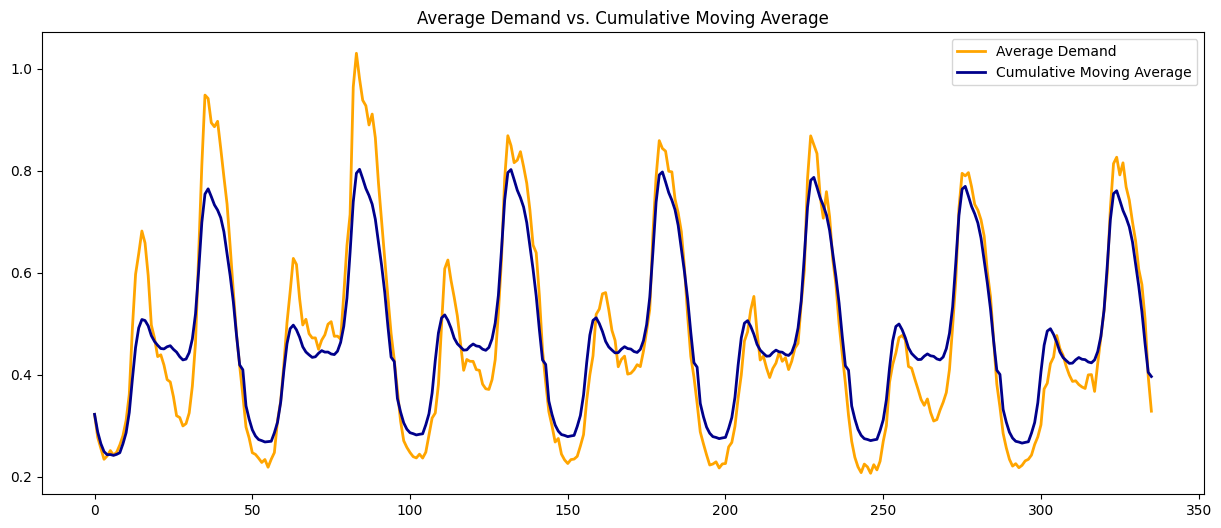

In [41]:
# Cumulative Moving Average

df_long['CMA_Deseasonalized'] = df_long.Deseasonalized_kWh.expanding().mean()

## Re-seasonalisation
df_long['CMA'] = df_long['CMA_Deseasonalized'] * df_long['Seasonal_Index']


plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['CMA'][:336], label='Cumulative Moving Average', color='darkblue', linewidth=2)
plt.title('Average Demand vs. Cumulative Moving Average')
plt.legend()
plt.show()

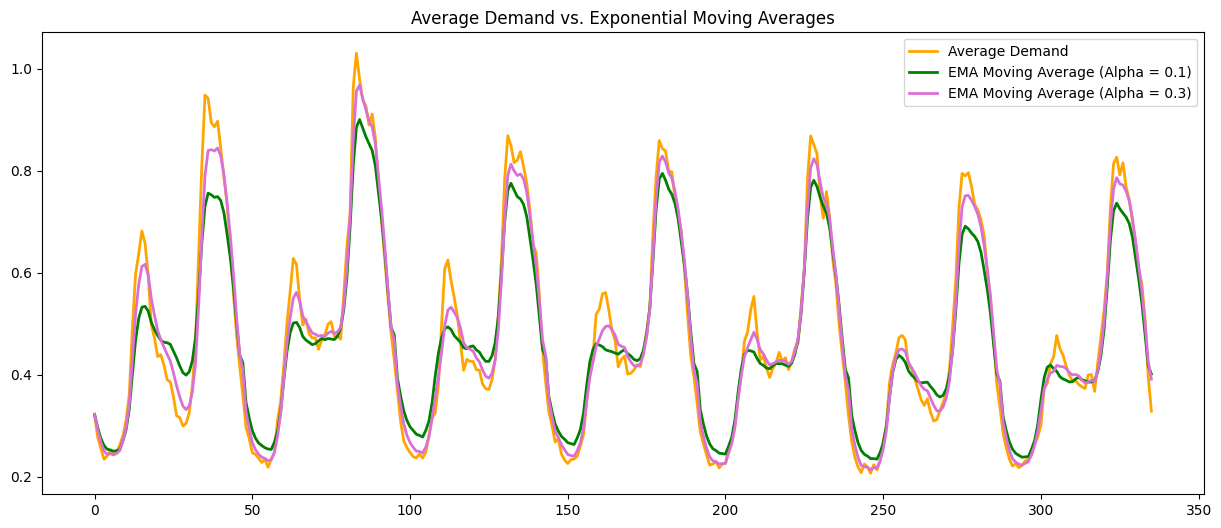

In [42]:
# Exponential Moving Average

df_long['EMA_0.1_Deseasonalized'] = df_long.Deseasonalized_kWh.ewm(alpha=0.1, adjust = False).mean()
df_long['EMA_0.3_Deseasonalized'] = df_long.Deseasonalized_kWh.ewm(alpha=0.3, adjust = False).mean()

## Re-seasonalisation
df_long['EMA_0.1'] = df_long['EMA_0.1_Deseasonalized'] * df_long['Seasonal_Index']
df_long['EMA_0.3'] = df_long['EMA_0.3_Deseasonalized'] * df_long['Seasonal_Index']


plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['EMA_0.1'][:336], label='EMA Moving Average (Alpha = 0.1)', color='green', linewidth=2)
plt.plot(df_long['EMA_0.3'][:336], label='EMA Moving Average (Alpha = 0.3)', color='orchid', linewidth=2)
plt.title('Average Demand vs. Exponential Moving Averages')
plt.legend()
plt.show()

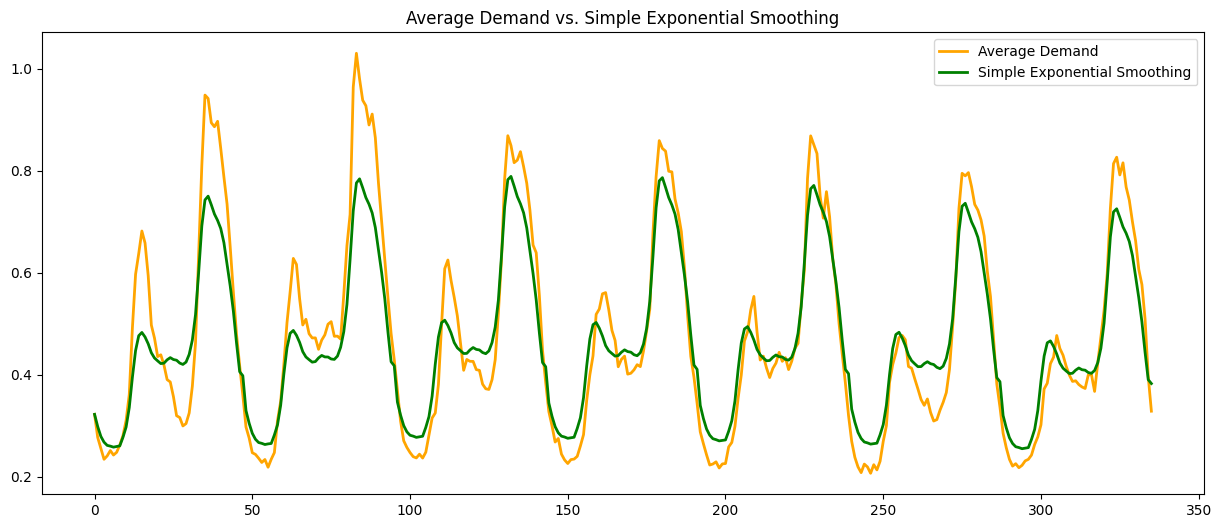

In [43]:
# Simple Exponential Smoothing

m = 48   # daily
alpha = 1/(2*m)
alpha

df_long['SES_Deseasonalised'] = SimpleExpSmoothing(df_long['Deseasonalized_kWh']).fit(smoothing_level=alpha,optimized=False,use_brute=True).fittedvalues

## Reseasonalized
df_long['SES'] = df_long['SES_Deseasonalised'] * df_long['Seasonal_Index']

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['SES'][:336], label='Simple Exponential Smoothing', color='green', linewidth=2)
plt.title('Average Demand vs. Simple Exponential Smoothing')
plt.legend()
plt.show()

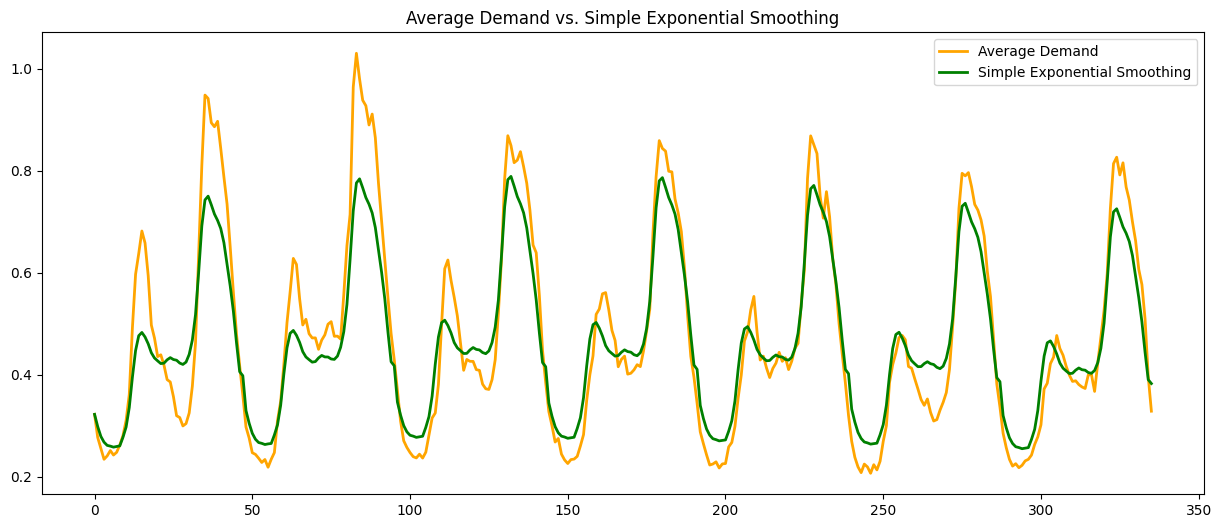

In [44]:
# Simple Exponential Smoothing (Single HWES)

m = 48   # daily
alpha = 1/(2*m)
alpha

df_long['SES_Deseasonalised'] = SimpleExpSmoothing(df_long['Deseasonalized_kWh']).fit(smoothing_level=alpha,optimized=False,use_brute=True).fittedvalues

## Reseasonalized
df_long['SES'] = df_long['SES_Deseasonalised'] * df_long['Seasonal_Index']

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['SES'][:336], label='Simple Exponential Smoothing', color='green', linewidth=2)
plt.title('Average Demand vs. Simple Exponential Smoothing')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


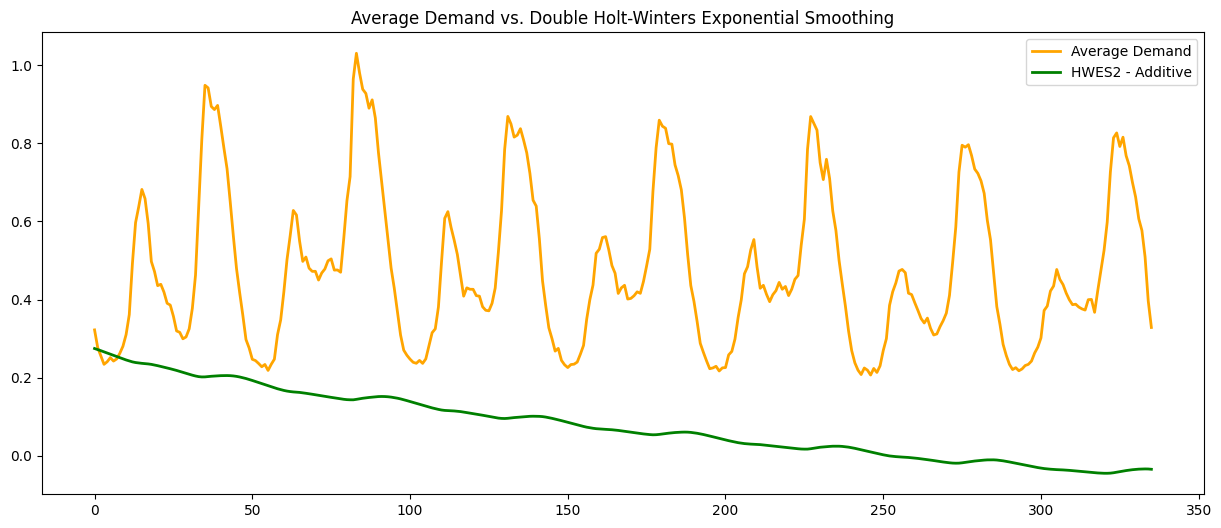

In [45]:
# Double Holt-Winters Exponential Smoothing

df_long['HWES2_ADD'] = ExponentialSmoothing(df_long['Avg_kWh'], trend = 'add').fit().fittedvalues

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['HWES2_ADD'][:336], label='HWES2 - Additive', color='green', linewidth=2)
plt.title('Average Demand vs. Double Holt-Winters Exponential Smoothing')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


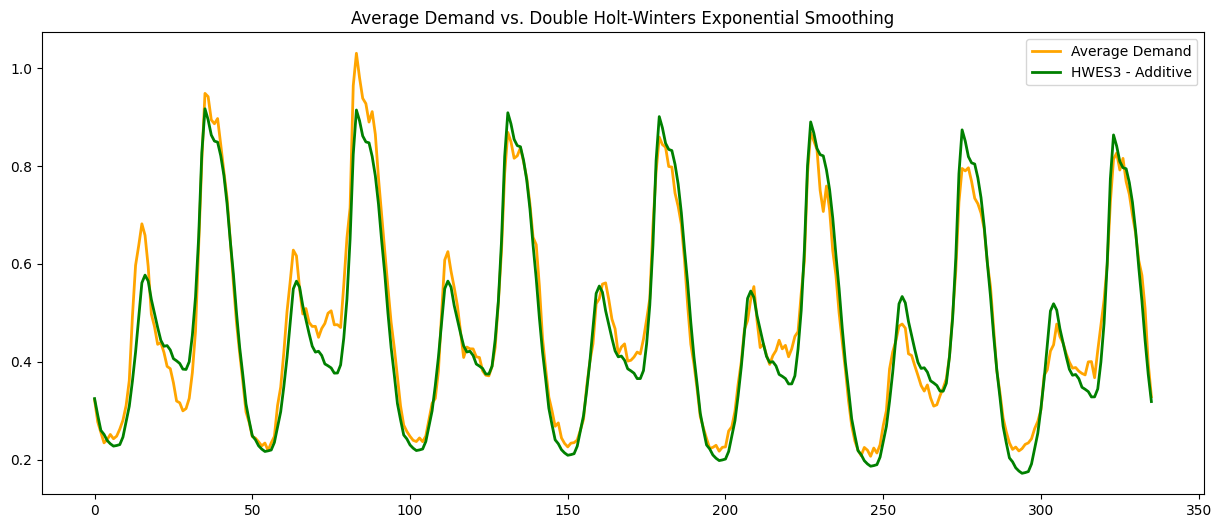

In [46]:
# Triple Holt-Winters Exponential Smoothing
df_long['HWES3_ADD'] = ExponentialSmoothing(df_long['Avg_kWh'], trend = 'add', seasonal='add', seasonal_periods = 48).fit().fittedvalues

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['HWES3_ADD'][:336], label='HWES3 - Additive', color='green', linewidth=2)
plt.title('Average Demand vs. Double Holt-Winters Exponential Smoothing')
plt.legend()
plt.show()

In [47]:
zero_rows = df_long[df_long['Avg_kWh'] == 0]
print(zero_rows[['Date', 'Period', 'Avg_kWh']])

            Date  Period  Avg_kWh
4516  2010-10-03       5      0.0
4517  2010-10-03       6      0.0
21987 2011-10-02       4      0.0
21988 2011-10-02       5      0.0
39795 2012-10-07       4      0.0
39796 2012-10-07       5      0.0
